In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
import matplotlib.pyplot as plt
import pickle
import joblib
import numpy as np

import sinter
import os

from qecsim.lattice_surgery.circuit import surgery_circuit
from qecsim.threshold_num.calc_threshold_new import calc_threshold_new
from qecsim.threshold_num.calc_threshold import threshold_approx

Adding the Observables manually doesn't really work. Stim therefore has a function called solve_flow_measurements:
<br>
<br>
    -> Implements the observables who satisfy needed flow i.e. X1 -> X1X2 in the normal CX case
<br>
    -> Keeps the corrective CZ/CX gates in mind

In [ ]:
surgery_circuit(distance = 3, round_split = 2, target_state_init="X+", control_state_init="X+", flow_observable = "X -> XX"). diagram("timeslice-svg")

TypeError: __mul__(): incompatible function arguments. The following argument types are supported:
    1. (self: stim._stim_sse2.Circuit, repetitions: int) -> stim._stim_sse2.Circuit

Invoked with: stim.Circuit('''
    SHIFT_COORDS(0, 0, 1)
    TICK
    H 9 22 20 11 13 24 26 42 46 40 48
    TICK
    CX 9 14 15 10 27 21 22 28 3 0 11 16 17 12 13 18 24 30 31 25 43 41 42 44 46 49 50 47
    TICK
    CX 9 3 16 10 28 21 22 15 4 0 11 5 18 12 13 7 24 17 32 25 44 41 42 38 46 43 51 47
    TICK
    CX 9 15 4 10 14 21 22 29 28 34 20 27 6 12 13 19 24 31 18 25 37 41 42 45 46 50 44 47
    TICK
    CX 9 4 5 10 15 21 22 16 29 34 20 14 7 12 13 8 24 18 19 25 38 41 42 39 46 44 45 47
    TICK
    H 9 22 20 11
    TICK
    MR 9 22 20 11 10 21 0 34
    TICK
    H 11
    TICK
    DETECTOR(2, 2, 0) rec[-8] rec[-32]
    DETECTOR(4, 4, 0) rec[-7] rec[-31]
    DETECTOR(4, 0, 0) rec[-6] rec[-30]
    DETECTOR(2, 6, 0) rec[-5] rec[-29]
    DETECTOR(2, 4, 0) rec[-4] rec[-28]
    DETECTOR(4, 2, 0) rec[-3] rec[-27]
    

In [4]:
# Load and concatenate all lists
stats_norm = joblib.load("lscx_singlerounds_combined.pkl")

# Load and concatenate all lists
stats_double = joblib.load("lscx_doublerounds_combined.pkl")

# Load and concatenate all lists
stats_3 = joblib.load("lscx_twothirdrounds_combined.pkl")


In [5]:
distances = sorted(set(stat.json_metadata["distance"] for stat in stats_norm))

red_dict_norm : dict = {}
red_dict_double : dict = {}
red_dict_3 : dict = {}

for d in range(0,len(distances)-1):
    red_dict_norm[distances[d]] = [stat for stat in stats_norm if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_double[distances[d]] = [stat for stat in stats_double if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_3[distances[d]] = [stat for stat in stats_3 if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]

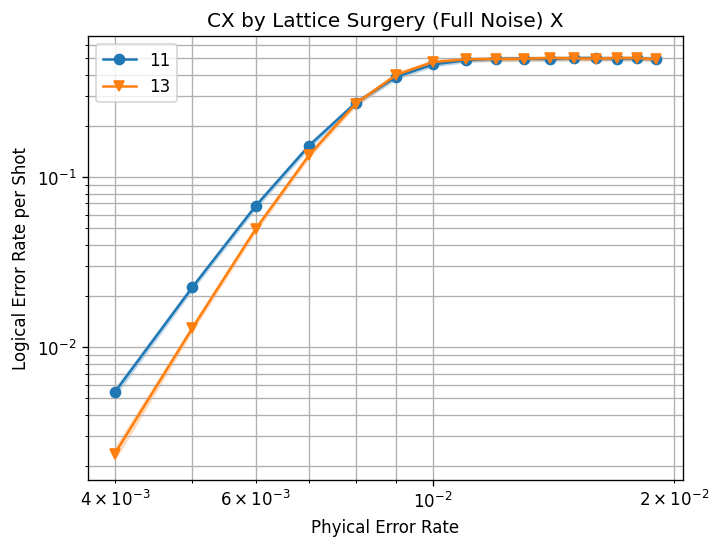

In [6]:
##################
# Plotting X Noise
##################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=red_dict_norm[11],
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_title("CX by Lattice Surgery (Full Noise) X")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [8]:
calc_threshold_new(red_dict_3[11])

0.008544162024383342

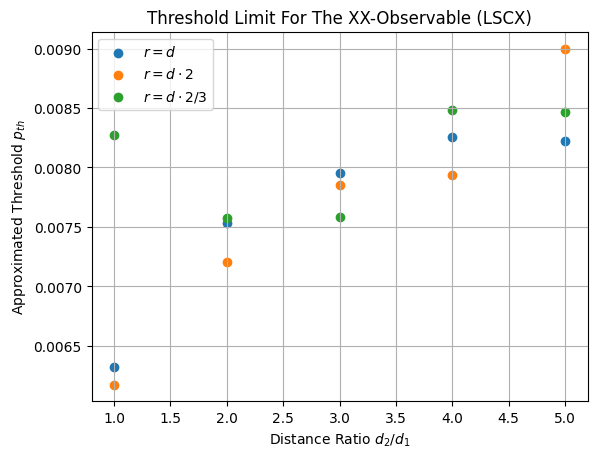

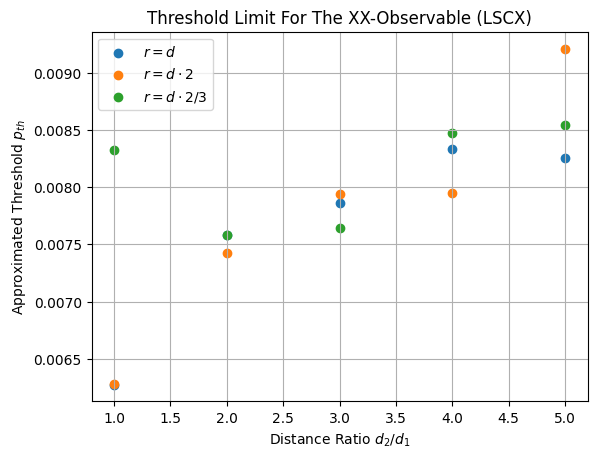

In [9]:
data_array_norm = []
data_array_double = []
data_array_3 = []

##########################
# Approx with first method
##########################

for pos, i in enumerate(distances[:-1]):
    try:
        data_array_norm.append([threshold_approx(red_dict_norm[i], p_max = 1e-2), pos + 1])
    except Exception as e:
        print(f"norm d={i} failed: {e}")

    try:
        data_array_double.append([threshold_approx(red_dict_double[i], p_max = 1e-2), pos + 1])
    except Exception as e:
        print(f"double d={i} failed: {e}")

    try:
        data_array_3.append([threshold_approx(red_dict_3[i], p_max = 1e-2), pos + 1])
    except Exception as e:
        print(f"twothird d={i} failed: {e}")


x_vals_norm = [point[1] for point in data_array_norm]
y_vals_norm = [point[0] for point in data_array_norm]
x_vals_double = [point[1] for point in data_array_double]
y_vals_double = [point[0] for point in data_array_double]
x_vals_3 = [point[1] for point in data_array_3]
y_vals_3 = [point[0] for point in data_array_3]


plt.scatter(x_vals_norm, y_vals_norm, label = "$r=d$")
plt.scatter(x_vals_double, y_vals_double, label = "$r = d \\cdot 2$")
plt.scatter(x_vals_3, y_vals_3, label = "$r = d \\cdot 2/3$")
plt.ylabel("Approximated Threshold $p_{th}$")
plt.xlabel("Distance Ratio $d_2/d_1$")
plt.title("Threshold Limit For The XX-Observable (LSCX)")
plt.legend()
plt.grid(True)

plt.figure()

###########################
# Approx with second method
###########################

data_array_norm = []
data_array_double = []
data_array_3 = []

for pos, i in enumerate(distances[:-1]):
    try:
        data_array_norm.append([calc_threshold_new(red_dict_norm[i]), pos + 1])
    except Exception as e:
        print(f"norm d={i} failed: {e}")

    try:
        data_array_double.append([calc_threshold_new(red_dict_double[i]), pos + 1])
    except Exception as e:
        print(f"double d={i} failed: {e}")

    try:
        data_array_3.append([calc_threshold_new(red_dict_3[i]), pos + 1])
    except Exception as e:
        print(f"twothird d={i} failed: {e}")


x_vals_norm = [point[1] for point in data_array_norm]
y_vals_norm = [point[0] for point in data_array_norm]
x_vals_double = [point[1] for point in data_array_double]
y_vals_double = [point[0] for point in data_array_double]
x_vals_3 = [point[1] for point in data_array_3]
y_vals_3 = [point[0] for point in data_array_3]


plt.scatter(x_vals_norm, y_vals_norm, label = "$r=d$")
plt.scatter(x_vals_double, y_vals_double, label = "$r = d \\cdot 2$")
plt.scatter(x_vals_3, y_vals_3, label = "$r = d \\cdot 2/3$")
plt.ylabel("Approximated Threshold $p_{th}$")
plt.xlabel("Distance Ratio $d_2/d_1$")
plt.title("Threshold Limit For The XX-Observable (LSCX)")
plt.legend()
plt.grid(True)